In [1]:
import pickle
from pathlib import Path
import sys
sys.path.append("/global/homes/y/yuejian/project/MLFF-distill/APPLICATIONS/electrolytes/observable_scripts/mean_square_displacement")
from msd_with_com import fit_diffusion, a2ps_to_m2s
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
def fit_diffusion_wrapper(tau, msd_cat, msd_anion, msd_solvent, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS):
    Dcat_a2ps, slope_c, b_c, mask_c = fit_diffusion(tau, msd_cat, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Dcat_1e10 = a2ps_to_m2s(Dcat_a2ps) * 1e10
    print(f"   → D(Na⁺) = {Dcat_1e10:.2f} ×10⁻¹⁰ m²/s ({Dcat_a2ps:.4f} Å²/ps)")


    Danion_a2ps, slope_a, b_a, mask_a = fit_diffusion(tau, msd_anion, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Danion_1e10 = a2ps_to_m2s(Danion_a2ps) * 1e10
    print(f"   → D(anion) = {Danion_1e10:.2f} ×10⁻¹⁰ m²/s ({Danion_a2ps:.4f} Å²/ps)")


    Dsolv_a2ps, slope_s, b_s, mask_s = fit_diffusion(tau, msd_solvent, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Dsolv_1e10 = a2ps_to_m2s(Dsolv_a2ps) * 1e10
    print(f"   → D(solvent) = {Dsolv_1e10:.2f} ×10⁻¹⁰ m²/s ({Dsolv_a2ps:.4f} Å²/ps)")

    return Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps

In [ ]:
msd_dict_path = Path("/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/ablate_distillation/observables/msd/converge_11_28/25ns/msd_dict_NaOTf — DME_298K_1M.pkl")

# Load the msd_dict files using pickle
with open(msd_dict_path, "rb") as f:
    msd_dict_naotf = pickle.load(f)

# You can now inspect msd_dicts, for example:
print("NaOTf — DME dict keys:", msd_dict_naotf.keys())

# Unpack variables from msd_dict_naotf
tau_naotf         = msd_dict_naotf["tau"]
msd_cat_naotf     = msd_dict_naotf["msd_cat"]
msd_anion_naotf   = msd_dict_naotf["msd_anion"]
msd_solvent_naotf = msd_dict_naotf["msd_solvent"]
dt_ps_naotf       = msd_dict_naotf["dt_ps"]
eq_time_ps_naotf  = msd_dict_naotf["EQ_TIME_PS"]

NaOTf — DME dict keys: dict_keys(['msd_cat', 'msd_anion', 'msd_solvent', 'tau', 'dt_ps', 'EQ_TIME_PS'])


In [ ]:
msd_anion_naotf.shape

(18953,)

   → D(Na⁺) = 7.49 ×10⁻¹⁰ m²/s (0.0749 Å²/ps)
   → D(anion) = 5.49 ×10⁻¹⁰ m²/s (0.0549 Å²/ps)
   → D(solvent) = 10.98 ×10⁻¹⁰ m²/s (0.1098 Å²/ps)
   → D(Na⁺) = 8.04 ×10⁻¹⁰ m²/s (0.0804 Å²/ps)
   → D(anion) = 6.21 ×10⁻¹⁰ m²/s (0.0621 Å²/ps)
   → D(solvent) = 10.67 ×10⁻¹⁰ m²/s (0.1067 Å²/ps)
   → D(Na⁺) = 8.40 ×10⁻¹⁰ m²/s (0.0840 Å²/ps)
   → D(anion) = 6.59 ×10⁻¹⁰ m²/s (0.0659 Å²/ps)
   → D(solvent) = 11.21 ×10⁻¹⁰ m²/s (0.1121 Å²/ps)
   → D(Na⁺) = 8.84 ×10⁻¹⁰ m²/s (0.0884 Å²/ps)
   → D(anion) = 7.56 ×10⁻¹⁰ m²/s (0.0756 Å²/ps)
   → D(solvent) = 11.46 ×10⁻¹⁰ m²/s (0.1146 Å²/ps)
   → D(Na⁺) = 8.07 ×10⁻¹⁰ m²/s (0.0807 Å²/ps)
   → D(anion) = 8.32 ×10⁻¹⁰ m²/s (0.0832 Å²/ps)
   → D(solvent) = 11.31 ×10⁻¹⁰ m²/s (0.1131 Å²/ps)
   → D(Na⁺) = 7.68 ×10⁻¹⁰ m²/s (0.0768 Å²/ps)
   → D(anion) = 8.84 ×10⁻¹⁰ m²/s (0.0884 Å²/ps)
   → D(solvent) = 11.21 ×10⁻¹⁰ m²/s (0.1121 Å²/ps)
   → D(Na⁺) = 7.37 ×10⁻¹⁰ m²/s (0.0737 Å²/ps)
   → D(anion) = 8.76 ×10⁻¹⁰ m²/s (0.0876 Å²/ps)
   → D(solvent) = 11.00 ×10⁻¹⁰ m²/s 

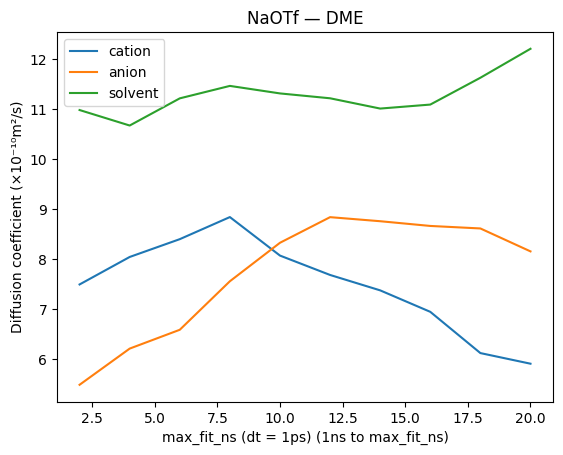

In [ ]:
min_fit_ps = 1000
max_fit_ps_list = np.linspace(2000,20000,10)
# naotf
D_cations = []
D_anions = []
D_solvent = []

for max_fit_ps in max_fit_ps_list:
    Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps = fit_diffusion_wrapper(tau_naotf, msd_cat_naotf, msd_anion_naotf, msd_solvent_naotf, min_fit_ps, max_fit_ps)
    D_cations.append(Dcat_1e10)
    D_anions.append(Danion_1e10)
    D_solvent.append(Dsolv_1e10)

max_fit_ps_list_ns = max_fit_ps_list / 1000

plt.plot(max_fit_ps_list_ns, D_cations,label="cation")
plt.plot(max_fit_ps_list_ns, D_anions,label="anion")
plt.plot(max_fit_ps_list_ns, D_solvent,label="solvent")
plt.legend()
plt.xlabel("max_fit_ns (dt = 1ps) (1ns to max_fit_ns)")
plt.ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
plt.title("NaOTf — DME")
plt.show()

In [ ]:
min_fit_ps = 1000
max_fit_ps_list = np.linspace(2000,20000,10)
# naotf
D_cations = []
D_anions = []
D_solvent = []

for max_fit_ps in max_fit_ps_list:
    Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps = fit_diffusion_wrapper(tau_naotf, msd_cat_naotf, msd_anion_naotf, msd_solvent_naotf, min_fit_ps, max_fit_ps)
    D_cations.append(Dcat_1e10)
    D_anions.append(Danion_1e10)
    D_solvent.append(Dsolv_1e10)

max_fit_ps_list_ns = max_fit_ps_list / 1000

plt.plot(max_fit_ps_list_ns, D_cations,label="cation")
plt.plot(max_fit_ps_list_ns, D_anions,label="anion")
plt.plot(max_fit_ps_list_ns, D_solvent,label="solvent")
plt.legend()
plt.xlabel("max_fit_ns (dt = 1ps) (1ns to max_fit_ns)")
plt.ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
plt.title("NaOTf — DME")
plt.show()